In [72]:
import pandas as pd

# Load all required CSVs
fantasy_df = pd.read_csv("Final_Fantasy_data.csv")
batting_df = pd.read_csv("Batting_data.csv")
bowling_df = pd.read_csv("Bowling_data.csv") 
fielding_df = pd.read_csv("Fielding_data.csv")
match_details_df = pd.read_csv("Match_details.csv")
matches_df = pd.read_csv("matches.csv")


In [73]:
print("Fantasy Points:")
fantasy_df.head()


Fantasy Points:


,season,match_id,match_name,home_team,away_team,venue,batting_innings,bowling_innings,fullName,Starting_11,Batting_FP,Bowling_FP,Fielding_FP,Total_FP,Dream Team,Captain,Vice Captain
0,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Sai Sudharsan,4,130,0,0,134,1,1,0
1,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Mohit Sharma,4,0,83,8,95,1,0,1
2,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Wriddhiman Saha,4,71,0,0,75,1,0,0
3,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Shubman Gill,4,56,0,0,60,1,0,0
4,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Noor Ahmad,4,0,54,0,58,1,0,0


In [74]:
print("Batting Stats:")
batting_df.head()

Batting Stats:


,match_id,season,match_name,home_team,away_team,venue,bowling_team,batting_team,batting_innings,fullName,batting_position,runs,balls,fours,sixes,strike_rate,Batting_FP
0,1359475,2023,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",GT,CSK,1,Devon Conway,1,1,6,0,0,16.66,1
1,1359475,2023,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",GT,CSK,1,Ruturaj Gaikwad,2,92,50,4,9,184.00,128
2,1359475,2023,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",GT,CSK,1,Moeen Ali,3,23,17,4,1,135.29,31
3,1359475,2023,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",GT,CSK,1,Ben Stokes,4,7,6,1,0,116.66,8
4,1359475,2023,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",GT,CSK,1,Ambati Rayudu,5,12,12,0,1,100.00,14


In [75]:
print("\nBowling Stats:")
bowling_df.head()


Bowling Stats:


,season,match_id,match_name,home_team,away_team,batting_team,bowling_team,venue,bowling_innings,fullName,...,wickets,economyRate,wides,noballs,LBW,Hitwicket,CaughtBowled,Bowled,Overs_Bowled,Bowling_FP
0,2023,1359475,GT v CSK,GT,CSK,CSK,GT,"Narendra Modi Stadium, Motera, Ahmedabad",1,Mohammed Shami,...,2,7.25,0,1,0,0,0,1,"[1, 3, 5, 19]",58
1,2023,1359475,GT v CSK,GT,CSK,CSK,GT,"Narendra Modi Stadium, Motera, Ahmedabad",1,Hardik Pandya,...,0,9.33,0,0,0,0,0,0,"[2, 7, 15]",0
2,2023,1359475,GT v CSK,GT,CSK,CSK,GT,"Narendra Modi Stadium, Motera, Ahmedabad",1,Josh Little,...,1,10.25,0,0,0,0,0,1,"[4, 11, 13, 20]",31
3,2023,1359475,GT v CSK,GT,CSK,CSK,GT,"Narendra Modi Stadium, Motera, Ahmedabad",1,Rashid Khan,...,2,6.50,0,0,0,0,0,0,"[6, 8, 10, 17]",52
4,2023,1359475,GT v CSK,GT,CSK,CSK,GT,"Narendra Modi Stadium, Motera, Ahmedabad",1,Alzarri Joseph,...,2,8.25,0,0,0,0,0,0,"[9, 14, 16, 18]",50


In [76]:
# Rename columns
batting_df_renamed = batting_df.rename(columns={'batsman': 'fullName'})
bowling_df_renamed = bowling_df.rename(columns={'bowler': 'fullName'})
fielding_df_renamed = fielding_df.rename(columns={'fielder': 'fullName'})

# Merge Fantasy + Batting
fantasy_batting = pd.merge(fantasy_df, batting_df_renamed, on=['match_id', 'fullName'], how='left')

# Merge with Bowling
fantasy_bat_bowl = pd.merge(fantasy_batting, bowling_df_renamed, on=['match_id', 'fullName'], how='left')

# 🔥 Drop duplicate columns from fielding before merge
cols_to_drop = ['match_name', 'season', 'venue', 'home_team', 'away_team']
fielding_df_renamed = fielding_df_renamed.drop(columns=cols_to_drop, errors='ignore')

# Final Merge
fantasy_full = pd.merge(fantasy_bat_bowl, fielding_df_renamed, on=['match_id', 'fullName'], how='left')

# Preview
print("✅ Final merged dataset:")
fantasy_full.head()

# Check missing
print("\n🔍 Missing values:")
fantasy_full.isnull().sum()


✅ Final merged dataset:

🔍 Missing values:


season_x                  0
match_id                  0
match_name_x              0
home_team_x               0
away_team_x               0
                      ...  
catching_FP           15243
stumping_FP           15243
direct_runout_FP      15243
indirect_runout_FP    15243
Fielding_FP_y         15243
Length: 65, dtype: int64

In [77]:
# Rename to use 'fullName'
batting_df_renamed = batting_df.rename(columns={'batsman': 'fullName'})
bowling_df_renamed = bowling_df.rename(columns={'bowler': 'fullName'})
fielding_df_renamed = fielding_df.rename(columns={'fielder': 'fullName'})

# Merge Fantasy with Batting
fantasy_batting = pd.merge(fantasy_df, batting_df_renamed, on=['match_id', 'fullName'], how='left')

# Merge with Bowling
fantasy_bat_bowl = pd.merge(fantasy_batting, bowling_df_renamed, on=['match_id', 'fullName'], how='left')

# Drop duplicate metadata columns before merging Fielding
columns_to_drop = ['match_name', 'season', 'venue', 'home_team', 'away_team']
fielding_df_renamed = fielding_df_renamed.drop(columns=columns_to_drop, errors='ignore')

# Merge with Fielding
fantasy_full = pd.merge(fantasy_bat_bowl, fielding_df_renamed, on=['match_id', 'fullName'], how='left')

# Final preview
print("✅ Final merged data:")
(fantasy_full.head())

# Optional: Check missing values
print("\n🕳️ Missing values summary:")
(fantasy_full.isnull().sum())


✅ Final merged data:

🕳️ Missing values summary:


season_x                  0
match_id                  0
match_name_x              0
home_team_x               0
away_team_x               0
                      ...  
catching_FP           15243
stumping_FP           15243
direct_runout_FP      15243
indirect_runout_FP    15243
Fielding_FP_y         15243
Length: 65, dtype: int64

In [78]:
# Fill all missing numerical values with 0
fantasy_full_cleaned = fantasy_full.fillna(0)

# Preview cleaned data
print("🧹 Cleaned data:")
fantasy_full_cleaned.head()


🧹 Cleaned data:


,season_x,match_id,match_name_x,home_team_x,away_team_x,venue_x,batting_innings_x,bowling_innings_x,fullName,Starting_11,...,Overs_Bowled,Bowling_FP_y,batting_team,bowling_innings,bowling_team,catching_FP,stumping_FP,direct_runout_FP,indirect_runout_FP,Fielding_FP_y
0,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Sai Sudharsan,4,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0
1,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Mohit Sharma,4,...,"[11, 13, 15]",83.0,CSK,2.0,GT,8.0,0.0,0.0,0.0,8.0
2,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Wriddhiman Saha,4,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0
3,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Shubman Gill,4,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0
4,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Noor Ahmad,4,...,"[5, 7, 9]",54.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0


In [79]:
print(fantasy_full_cleaned.columns.tolist())



['season_x', 'match_id', 'match_name_x', 'home_team_x', 'away_team_x', 'venue_x', 'batting_innings_x', 'bowling_innings_x', 'fullName', 'Starting_11', 'Batting_FP_x', 'Bowling_FP_x', 'Fielding_FP_x', 'Total_FP', 'Dream Team', 'Captain', 'Vice Captain', 'season_y', 'match_name_y', 'home_team_y', 'away_team_y', 'venue_y', 'bowling_team_x', 'batting_team_x', 'batting_innings_y', 'batting_position', 'runs', 'balls', 'fours', 'sixes', 'strike_rate', 'Batting_FP_y', 'season', 'match_name', 'home_team', 'away_team', 'batting_team_y', 'bowling_team_y', 'venue', 'bowling_innings_y', 'overs', 'total_balls', 'dots', 'maidens', 'conceded', 'foursConceded', 'sixesConceded', 'wickets', 'economyRate', 'wides', 'noballs', 'LBW', 'Hitwicket', 'CaughtBowled', 'Bowled', 'Overs_Bowled', 'Bowling_FP_y', 'batting_team', 'bowling_innings', 'bowling_team', 'catching_FP', 'stumping_FP', 'direct_runout_FP', 'indirect_runout_FP', 'Fielding_FP_y']


In [80]:
fantasy_full_cleaned = fantasy_full_cleaned.rename(columns={
    'economyRate': 'economy_rate',
    'catching_FP': 'catches',
    'stumping_FP': 'stumpings',
})



In [81]:
fantasy_full_cleaned['run_outs'] = (
    fantasy_full_cleaned['direct_runout_FP'].fillna(0) +
    fantasy_full_cleaned['indirect_runout_FP'].fillna(0)
)


In [82]:
feature_cols = ['runs', 'balls', 'fours', 'sixes', 'economy_rate', 'strike_rate', 'wickets', 'maidens', 'wides', 'noballs', 'catches', 'stumpings', 'run_outs']
missing = [col for col in feature_cols if col not in fantasy_full_cleaned.columns]
print("Missing columns:", missing)


Missing columns: []


In [83]:
X = fantasy_full_cleaned[feature_cols]
y = fantasy_full_cleaned['Total_FP']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (22362, 13)
y shape: (22362,)


In [84]:
print(X.head())
print(y.head())


   runs  balls  fours  sixes  economy_rate  strike_rate  wickets  maidens  \
0  96.0   47.0    8.0    6.0          0.00       204.25      0.0      0.0   
1   0.0    0.0    0.0    0.0         12.00         0.00      3.0      0.0   
2  54.0   39.0    5.0    1.0          0.00       138.46      0.0      0.0   
3  39.0   20.0    7.0    0.0          0.00       195.00      0.0      0.0   
4   0.0    0.0    0.0    0.0          5.66         0.00      2.0      0.0   

   wides  noballs  catches  stumpings  run_outs  
0    0.0      0.0      0.0        0.0       0.0  
1    0.0      0.0      8.0        0.0       0.0  
2    0.0      0.0      0.0        0.0       0.0  
3    0.0      0.0      0.0        0.0       0.0  
4    3.0      0.0      0.0        0.0       0.0  
0    134
1     95
2     75
3     60
4     58
Name: Total_FP, dtype: int64


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [86]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [88]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [89]:
y_pred = model.predict(X_test)


In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 2.04
RMSE: 3.96
R² Score: 0.99


In [91]:
import joblib

joblib.dump(model, "fantasy_point_predictor.pkl")


['fantasy_point_predictor.pkl']

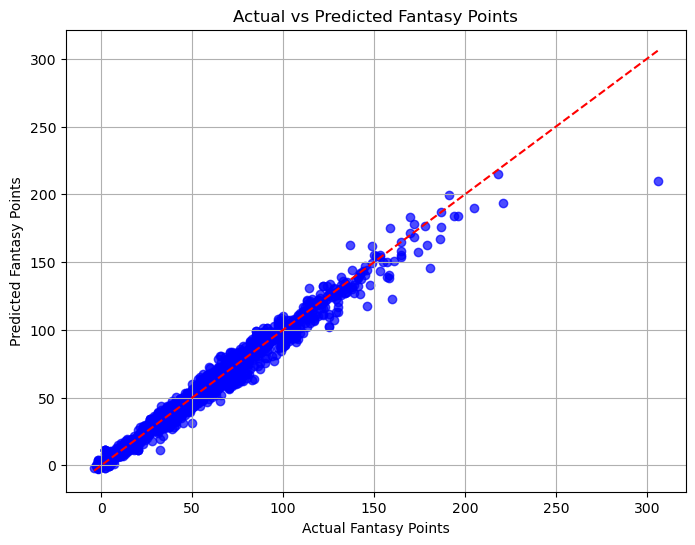

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.xlabel("Actual Fantasy Points")
plt.ylabel("Predicted Fantasy Points")
plt.title("Actual vs Predicted Fantasy Points")
plt.grid(True)
plt.show()


In [93]:
# Sample input (replace with real values)
new_player = {
    'runs': 45, 'balls': 30, 'fours': 4, 'sixes': 2, 'economy_rate': 0,
    'strike_rate': 150, 'wickets': 0, 'maidens': 0, 'wides': 0,
    'noballs': 0, 'catches': 1, 'stumpings': 0, 'run_outs': 1
}

import pandas as pd

new_df = pd.DataFrame([new_player])
predicted_points = model.predict(new_df)[0]
print(f"Predicted Fantasy Points: {predicted_points:.2f}")


Predicted Fantasy Points: 65.77


In [94]:
 fantasy_full_cleaned['Predicted_FP'] = model.predict(X)
top_players = fantasy_full_cleaned[['fullName', 'Predicted_FP']].sort_values(by='Predicted_FP', ascending=False)
print(top_players.head(11))  # Top 11 players


               fullName  Predicted_FP
13026      Yuvraj Singh        242.19
415         Rashid Khan        239.09
17601       Chris Gayle        225.25
18283     Paul Valthaty        223.09
21857     Sohail Tanvir        220.12
16903   Ravindra Jadeja        220.10
18250      Yuvraj Singh        217.75
22340  Brendon McCullum        215.46
16772    Kieron Pollard        215.24
17204      Shane Watson        213.48
801      Mitchell Marsh        213.02


In [95]:
# Save
import joblib
joblib.dump(model, "fantasy_model.pkl")

# Load
# model = joblib.load("fantasy_model.pkl")


['fantasy_model.pkl']

In [96]:
joblib.dump(model, "fantasy_full_cleaned.pkl")


['fantasy_full_cleaned.pkl']

In [97]:
fantasy_full_cleaned.to_csv('fantasy_full_cleaned.csv', index=False)


In [98]:
pd.read_csv("fantasy_full_cleaned.csv")

,season_x,match_id,match_name_x,home_team_x,away_team_x,venue_x,batting_innings_x,bowling_innings_x,fullName,Starting_11,...,batting_team,bowling_innings,bowling_team,catches,stumpings,direct_runout_FP,indirect_runout_FP,Fielding_FP_y,run_outs,Predicted_FP
0,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Sai Sudharsan,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,133.730000
1,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Mohit Sharma,4,...,CSK,2.0,GT,8.0,0.0,0.0,0.0,8.0,0.0,95.863333
2,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Wriddhiman Saha,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,75.400000
3,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Shubman Gill,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,62.390000
4,2023,1370353,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",1,2,Noor Ahmad,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,58.080000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22357,2008,335982,RCB v KKR,RCB,KKR,"M.Chinnaswamy Stadium, Bengaluru",2,1,Sunil Joshi,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,7.330000
22358,2008,335982,RCB v KKR,RCB,KKR,"M.Chinnaswamy Stadium, Bengaluru",2,1,Rahul Dravid,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,6.000000
22359,2008,335982,RCB v KKR,RCB,KKR,"M.Chinnaswamy Stadium, Bengaluru",2,1,Virat Kohli,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000
22360,2008,335982,RCB v KKR,RCB,KKR,"M.Chinnaswamy Stadium, Bengaluru",2,1,Wasim Jaffer,4,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.990000


In [99]:
fantasy_full_cleaned['venue_x'].values

array(['Narendra Modi Stadium, Motera, Ahmedabad',
       'Narendra Modi Stadium, Motera, Ahmedabad',
       'Narendra Modi Stadium, Motera, Ahmedabad', ...,
       'M.Chinnaswamy Stadium, Bengaluru',
       'M.Chinnaswamy Stadium, Bengaluru',
       'M.Chinnaswamy Stadium, Bengaluru'], dtype=object)

In [100]:
print(fantasy_full_cleaned['venue_x'].unique())

['Narendra Modi Stadium, Motera, Ahmedabad'
 'MA Chidambaram Stadium, Chepauk, Chennai'
 'M.Chinnaswamy Stadium, Bengaluru' 'Wankhede Stadium, Mumbai'
 'Eden Gardens, Kolkata' 'Arun Jaitley Stadium, Delhi'
 'Himachal Pradesh Cricket Association Stadium, Dharamsala'
 'Rajiv Gandhi International Stadium, Uppal, Hyderabad'
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'
 'Sawai Mansingh Stadium, Jaipur'
 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh'
 'Barsapara Cricket Stadium, Guwahati' 'Brabourne Stadium, Mumbai'
 'Dr DY Patil Sports Academy, Navi Mumbai'
 'Maharashtra Cricket Association Stadium, Pune'
 'Dubai International Cricket Stadium' 'Sharjah Cricket Stadium'
 'Sheikh Zayed Stadium, Abu Dhabi'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam'
 'Holkar Cricket Stadium, Indore' 'Green Park, Kanpur'
 'Saurashtra Cricket Association Stadium, Rajkot'
 'Shaheed Veer Narayan Singh International Stadium, Raipur'
 'JSCA In

In [132]:
import pickle
from sklearn.ensemble import RandomForestRegressor

# After training your model:
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save model
with open('fantasy_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [134]:
import pickle

with open('fantasy_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Now model.predict(X) will work


In [140]:
from sklearn.ensemble import RandomForestRegressor
import pickle

# Suppose you have X_train and y_train
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save the trained model
with open('fantasy_model.pkl', 'wb') as f:
    pickle.dump(model, f)



In [138]:
import pickle

with open('fantasy_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(type(model))  # <- This will tell you if it's really a model or not


<class 'numpy.ndarray'>
